In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class Differentiate: 
    def __init__(self, r0, params, *args): #initialize the class
        """
        r0 should be a 3D Array of the initial position \n
        params should be a 3D Array of the three parameters \n
        """
        self.sigma_, self.rho_, self.beta_  = params
        self.r_ = np.array([r0]) #Values of the evolution
    
    def simulate(self, T, dt):
        """
        Simulate the trajectory for a time T with steps dt
        """
        N = int(T/dt) #Number of steps
        t=0
        for i in range(N):
            K1 = self.__Func(t, self.r_[i])
            K2 = K1 + self.__Func(t+dt/2, self.r_[i] + K1*dt/2)
            self.r_ = np.append(self.r_, [self.r_[i]+K2*dt], axis=0)
            t += dt

    def __Func(self, t, r): #differential function
        dx = self.sigma_*(r[1]-r[0])
        dy = r[0]*(self.rho_-r[2])-r[1]
        dz = r[0]*r[1] - self.beta_*r[2]
        return np.array([dx, dy, dz])
    

    def Plot(self): #plot Data
        """
        Plot the trajectory within time [0, T] and step dt\n
        Four plots are generated: (x,y), (x,z), (y,z), (x,y,z)        
        """
        fig = plt.figure(figsize=(10,10))
        fig.suptitle("Plots of the simulated data")
        ax = fig.add_subplot(221) #First subplot
        ax.plot(self.r_[:,0], self.r_[:,1])
        ax.set_title("X(t) vs Y(t)")
        ax.set_xlabel("x(t)")
        ax.set_ylabel("y(t)")

        ax = fig.add_subplot(222) #Second subplot
        ax.plot(self.r_[:,0], self.r_[:,2])
        ax.set_title("X(t) vs Z(t)")
        ax.set_xlabel("x(t)")
        ax.set_ylabel("z(t)")

        ax = fig.add_subplot(223) #Third subplot
        ax.plot(self.r_[:,1], self.r_[:,2])
        ax.set_title("Y(t) vs Z(t)")
        ax.set_xlabel("y(t)")
        ax.set_ylabel("z(t)")

        ax = fig.add_subplot(224, projection='3d') #Fourth subplot
        ax.scatter(self.r_[:,0], self.r_[:,1], self.r_[:,2])
        ax.set_title("X(t) vs Y(t) vs Z(t)")
        ax.set_xlabel("x(t)")
        ax.set_ylabel("y(t)")
        ax.set_zlabel("z(t)")

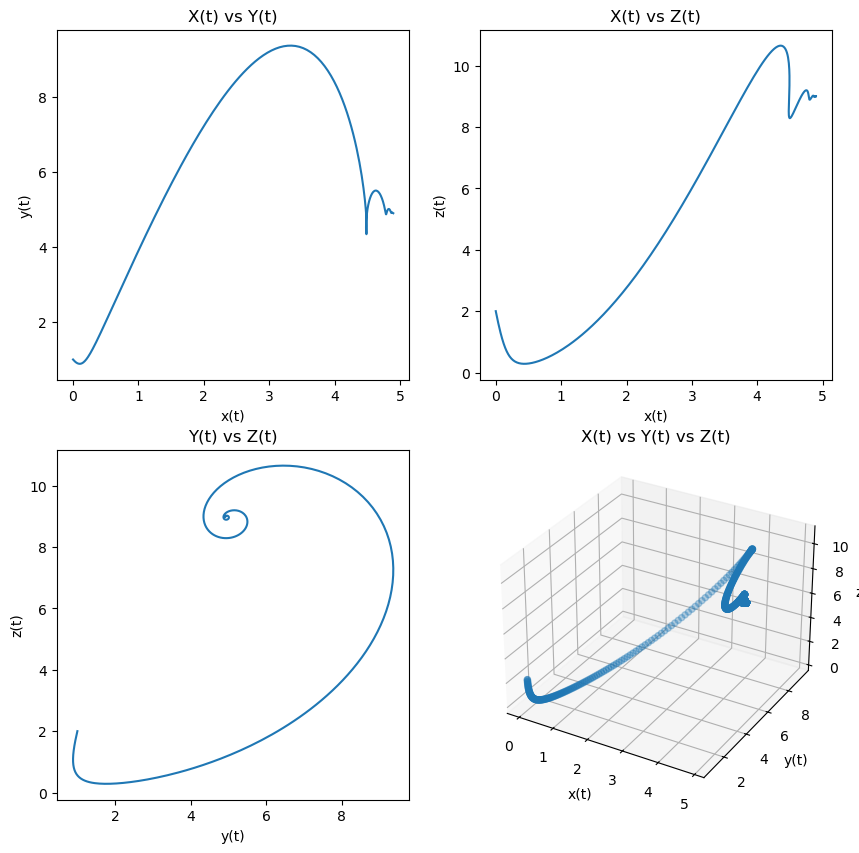

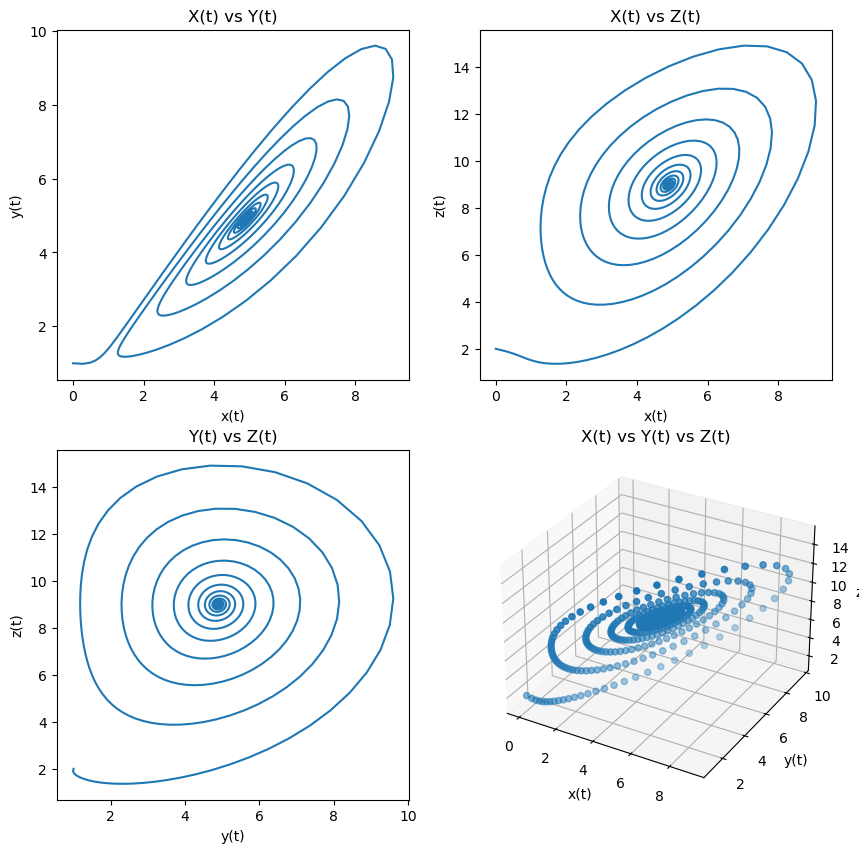

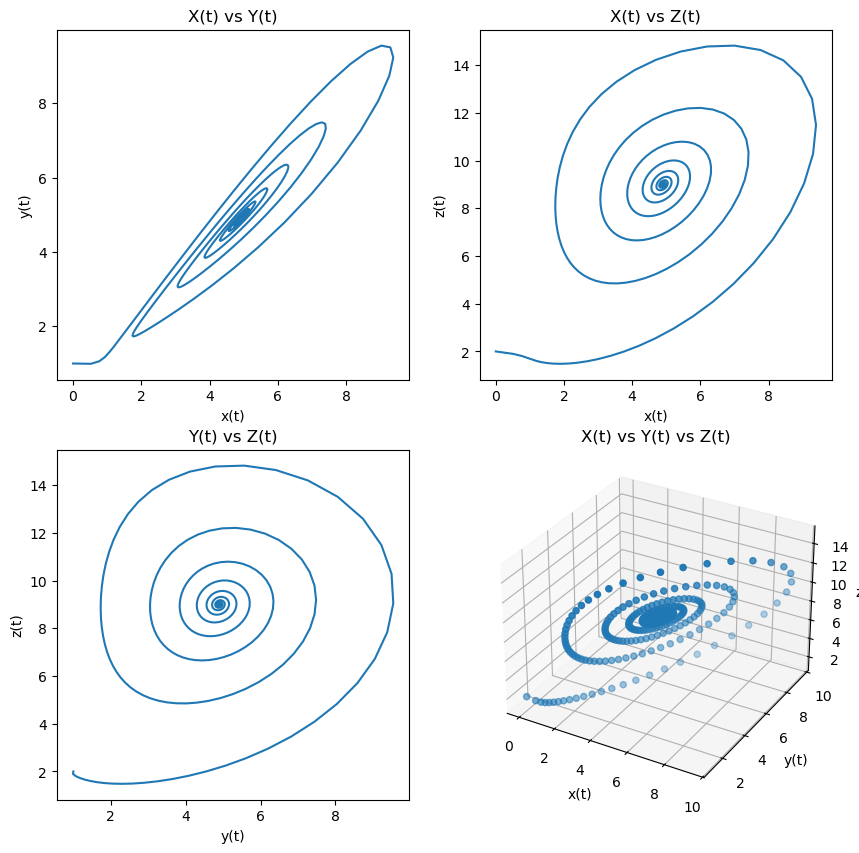

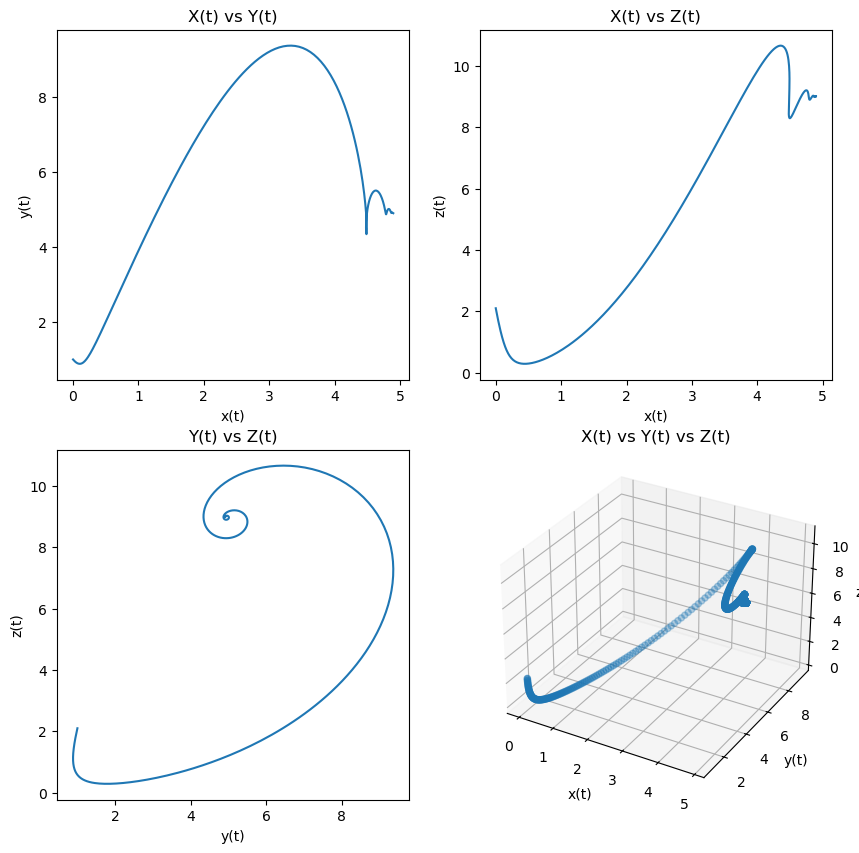

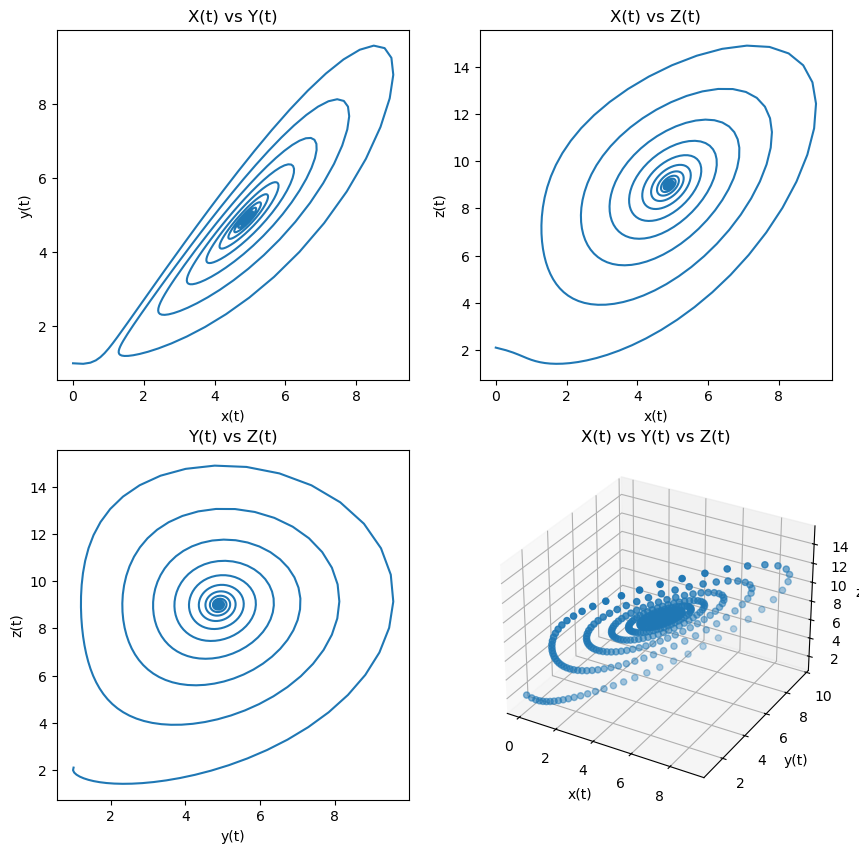

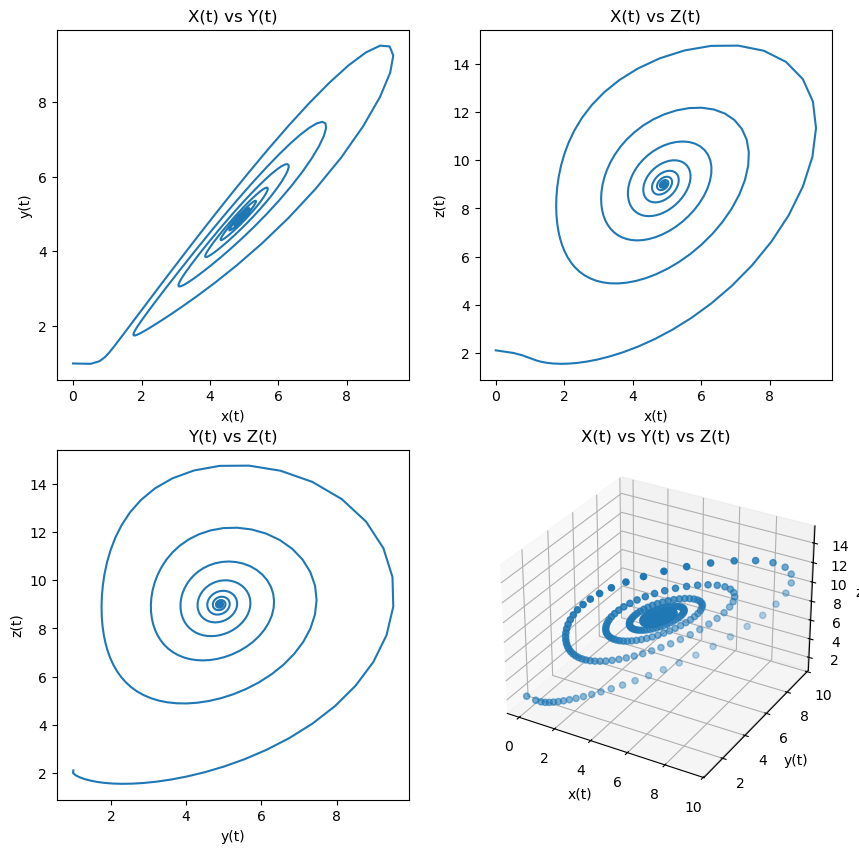

In [41]:
params = [(0.5, 10, 8/3), (15, 10, 8/3), (28, 10, 8/3)]
r0 = [[0,1,2], [0,1,2.1]]
for i in range(2):
    for j in range(3):               
        diff = Differentiate(r0[i], params[j])
        diff.simulate(100, 0.01)
        diff.Plot()